# 7. What is the average number of aces per match? 

#### It imports three libraries: pandas for reading and processing data, numpy for numerical calculations (such as creating histogram bins), and matplotlib.pyplot for plotting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### It saves the path to the cleaned data folder, reads the events file, and then—using the `score_ready` column filter (created by the Validator notebook)—retains only valid and complete matches in `ev_ok`.

In [2]:
IN_DIR = "cleaned_data"

event = pd.read_parquet(f"{IN_DIR}/event.parquet")
ev_ok = event.loc[event["score_ready"]].copy()
print(f"Matches passing quality gate: {len(ev_ok)} / {len(event)}")

Matches passing quality gate: 14413 / 16873


#### It reads the match statistics file, retains only the rows related to "ace" at the overall match level (`period='ALL'`), and then performs an inner join with `ev_ok` to ensure only verified matches are included.

In [3]:
stats_df = pd.read_parquet(f"{IN_DIR}/statistics.parquet")
aces = stats_df[(stats_df["statistic_name"] == "aces") & (stats_df["period"] == "ALL")][["match_id", "home_value", "away_value"]]
aces = aces.merge(ev_ok[["match_id"]], on="match_id", how="inner")
aces["total_aces"] = aces.home_value + aces.away_value
print("Matches used:", len(aces))
print("Average aces per match:", round(aces["total_aces"].mean(), 2))
print("Median:", aces["total_aces"].median())

Matches used: 10509
Average aces per match: 5.34
Median: 4.0


#### It plots a histogram of `total_aces` using bins of size 2, ranging from 0 to the maximum value, in light blue (#0099CC). Two vertical lines are added—one for the mean (green, dashed) and one for the median (orange, dotted)—to visualize the gap between them (an indicator of skewness)
####  The title, axis labels, and legend are set, the top and right borders are removed, and the plot is saved to the file `q7_aces.png`

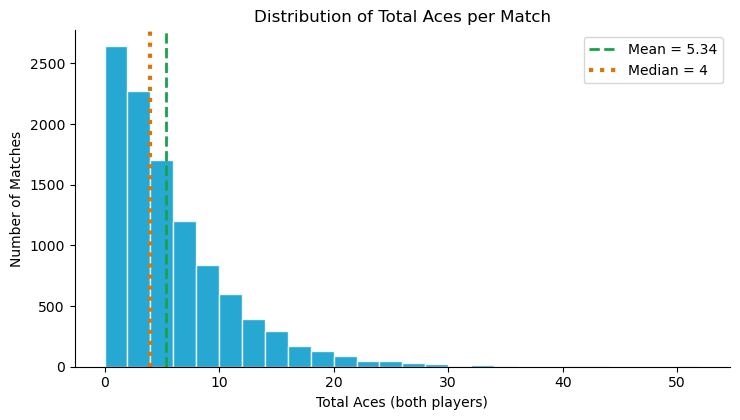

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4.3))
bins = np.arange(0, aces["total_aces"].max() + 2, 2)
ax.hist(aces["total_aces"], bins=bins, color="#0099CC", alpha=0.85, edgecolor="white")
ax.axvline(aces["total_aces"].mean(), color="#16a34a", linestyle="--", linewidth=2, label=f"Mean = {aces['total_aces'].mean():.2f}")
ax.axvline(aces["total_aces"].median(), color="#d97706", linestyle=":", linewidth=3, label=f"Median = {aces['total_aces'].median():.0f}")
ax.set_title("Distribution of Total Aces per Match")
ax.set_xlabel("Total Aces (both players)")
ax.set_ylabel("Number of Matches")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("charts/q7_aces.png", dpi=170)
plt.show()

The mean total number of aces per match is 5.34, while the median is 4; this discrepancy indicates a right-skewed distribution, which is evident in the chart.

Additionally, approximately 50% of the matches feature between 0 and 6 aces, suggesting that most matches are not serve-dominated.

Some outliers appear on the right side of the chart; these are genuine data points—stemming from long, five-set matches—and were therefore retained, causing the distribution to skew to the right.